# CV Project

## Preprocessing

In [ ]:
%matplotlib tk

In [ ]:
from PIL import Image

from matplotlib.widgets import Slider, Button

import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import os
import numpy as np
import math

In [ ]:
image_dir = Path("./development_set")
data = []

print("Scanning image resolutions... this might take a minute.")
   
for img_path in image_dir.rglob('*.jpg'):
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            data.append({
                "Width": width,
                "Height": height
            })
    except Exception as e:
        pass

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Width", y="Height", alpha=0.5, edgecolor=None)
plt.title("Raw Image Dimensions")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

In [ ]:
HEIGHT = 1920 
WIDTH = 1080

input_dir = Path("./development_set")
output_dir = Path("./processed_images")

In [ ]:
def process_and_save_image(file_path, out_path):
    img = cv2.imread(str(file_path))
    
    if img is None:
        print(f"Warning: Could not read {file_path}")
        return

    img_resized = cv2.resize(img, dsize=(HEIGHT, WIDTH)) 

    img_normalized = cv2.normalize(
        img_resized, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U
    )

    cv2.imwrite(str(out_path), img_normalized)

In [ ]:
for img_path in input_dir.rglob('*.jpg'):
    rel_path = img_path.relative_to(input_dir)
    out_path = output_dir / rel_path
    out_path.parent.mkdir(parents=True, exist_ok=True)
    
    process_and_save_image(img_path, out_path)

print(f"Done! All images processed and saved to {output_dir}")

# Ball Detection

* Color Masking
* Contour Filtering

In [1]:
from billard_detector_main import detect_billiard_balls, run_on_directory
from pathlib import Path
import os
import cv2

In [ ]:
run_on_directory(Path("./processed_images"))

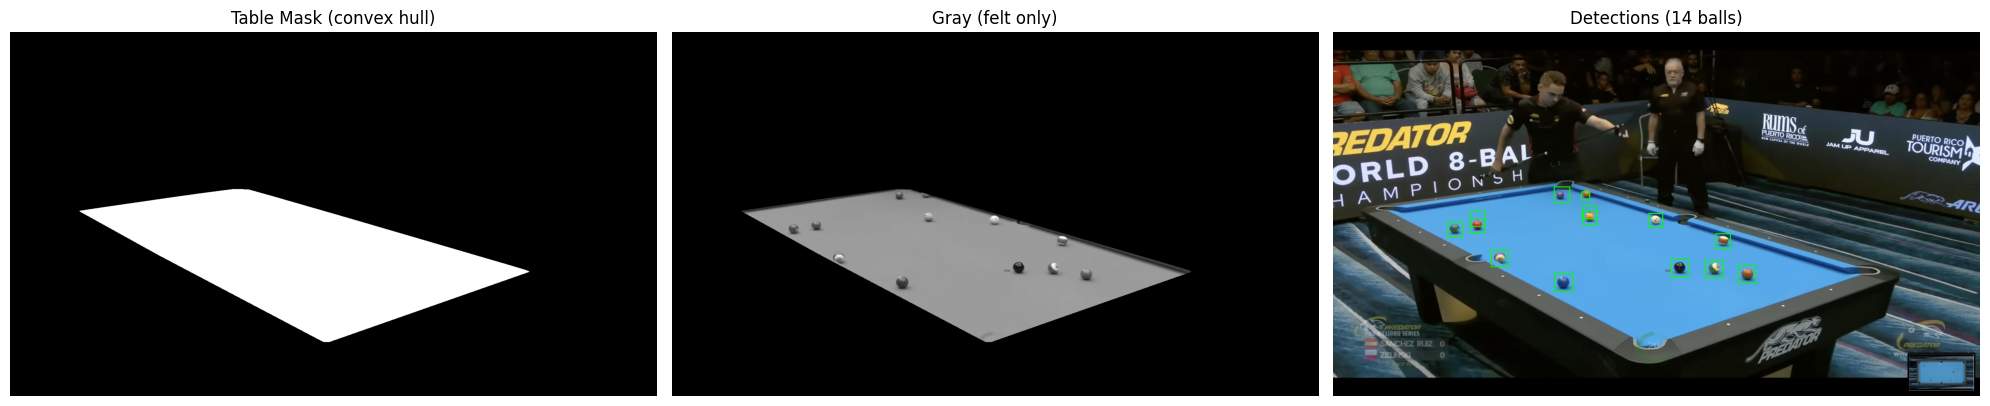

In [2]:
output_dir = Path("./processed_images")
img_path = os.path.join(output_dir, '4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg')
frame = cv2.imread(img_path)
output_frame, balls = detect_billiard_balls(frame, debug=True)

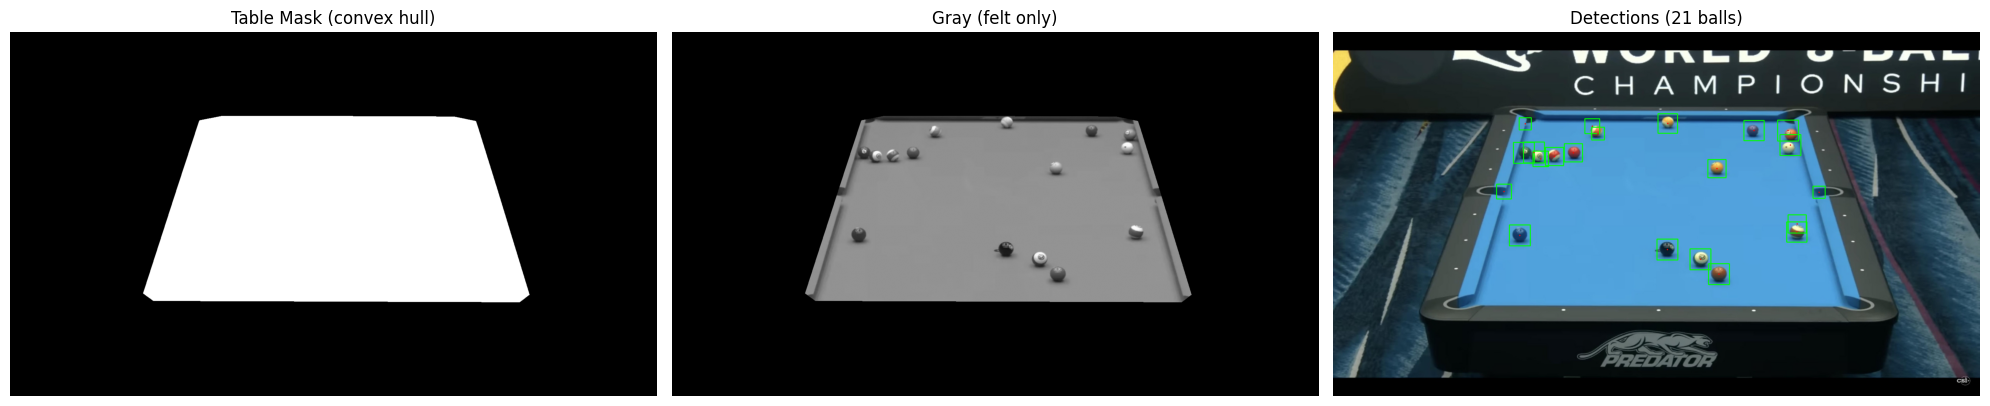

In [3]:
img_path = os.path.join(output_dir, '3f_png.rf.81c7e132365ef95bb19380ca389025f6.jpg')
frame = cv2.imread(img_path)
output_frame, balls = detect_billiard_balls(frame, debug=True)

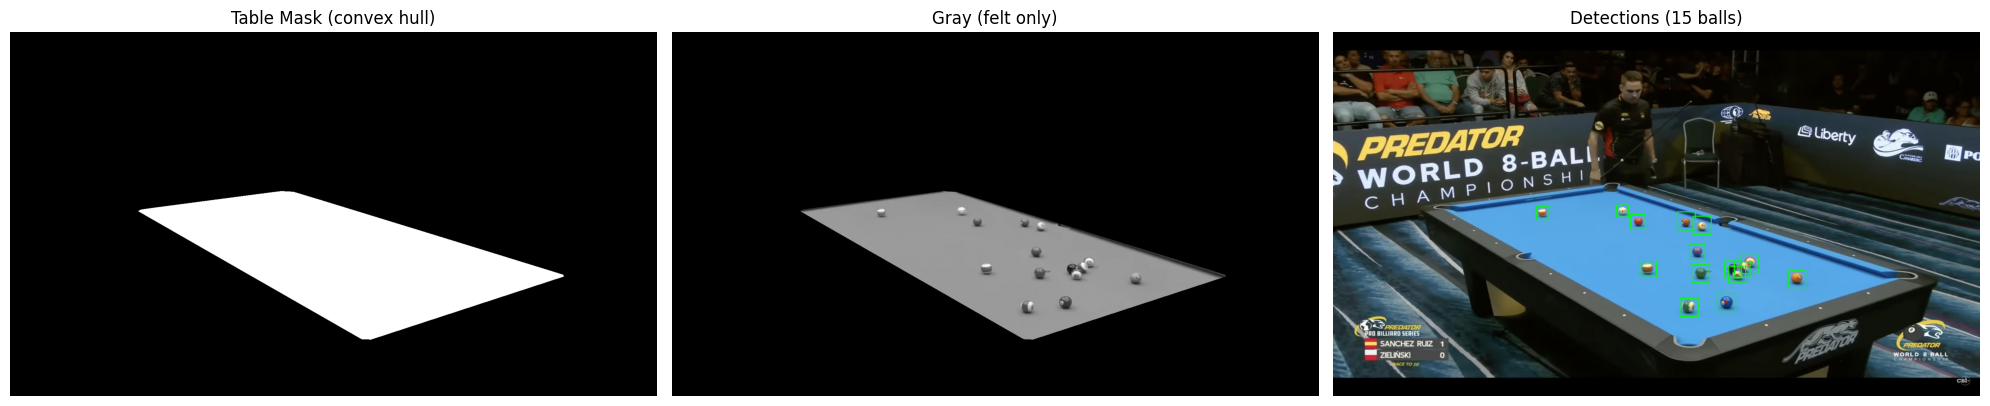

In [4]:
img_path = os.path.join(output_dir, '5a_png.rf.bae1d48b3d2d96a990799b836ecebcbb.jpg')
frame = cv2.imread(img_path)
output_frame, balls = detect_billiard_balls(frame, debug=True)

## Output File Format

In [ ]:
def identify_balls(path_aux):
    img_path = os.path.join(output_dir, path_aux)
    frame = cv2.imread(img_path)
    
    if frame is None:
        print(f"Error: Could not load {img_path}")
        return 0, []
    
    img_height, img_width = frame.shape[:2]
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower_blue = np.array([100, 40, 160])
    upper_blue = np.array([135, 255, 255])
    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # 2. Focus only on the table area
    contours, _ = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0, []
    
    table_contour = max(contours, key=cv2.contourArea)
    table_surface = np.zeros_like(blue_mask)
    cv2.drawContours(table_surface, [cv2.convexHull(table_contour)], -1, 255, -1)

    # 3. Preprocess for Circle Detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray_table = cv2.bitwise_and(gray, gray, mask=table_surface)
    gray_blur = cv2.medianBlur(gray_table, 5)

    circles = cv2.HoughCircles(
        gray_blur, 
        cv2.HOUGH_GRADIENT, 
        dp=1.1, 
        minDist=14,       
        param1=80,        # only looking at objects and not textures
        param2=18,        # looking for round shapes
        minRadius=6,      
        maxRadius=25
    )

    balls_data = []
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        for i, (x, y, r) in enumerate(circles):
            padding = int(r * 0.2)
            # Normalize coordinates
            balls_data.append({
                "number": i + 1,
                "xmin": float(max(0, x - r - padding)) / img_width,
                "xmax": float(min(img_width, x + r + padding)) / img_width,
                "ymin": float(max(0, y - r - padding)) / img_height,
                "ymax": float(min(img_height, y + r + padding)) / img_height
            })

    return len(balls_data), balls_data

In [ ]:
import json

# Define the directory
dev_set_path = "development_set"
all_results = []

# 1. Cycle over all images in the folder
for img_name in os.listdir(dev_set_path):
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        
        # 2. Get the relative path for the JSON "image_path" field
        relative_path = os.path.join(dev_set_path, img_name)
        
        # 3. Run the detection logic
        ball_count, balls_list = identify_balls(img_name)
        
        # 4. Create the dictionary for this specific image
        image_data = {
            "image_path": relative_path,
            "num_balls": ball_count,
            "balls": balls_list
        }
        
        all_results.append(image_data)

# 6. Convert the entire list to a JSON string at the very end
json_output = json.dumps(all_results, indent=4)

# Save to a file
with open("output.json", "w") as f:
    f.write(json_output)